# Checking the preprocessed data
In this notebook, we'll analyze the preprocessed datasets to check their quality.

# Imports and paths

In [1]:
%cd ..

/home/cdauvill/inria/motif


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from hydra import compose, initialize
from hydra.utils import instantiate
from motif.data.utils import read_variables_dict

In [4]:
# context initialization
with initialize(version_base=None, config_path="../configs"):
    cfg = compose(
        config_name="notebooks",
        overrides=["paths=local"],
    )
paths = cfg["paths"]
sources_cfg = cfg["sources"]

In [5]:
sources_cfg

{'tc_primed': {'era5': {'variables': ['pressure_msl', 'u_wind_10m', 'v_wind_10m', 'sst', 'dist_to_center'], 'input_only': ['sst'], 'output_only': ['dist_to_center']}, 'pmw': {'AMSR2_GCOMW1': {'variables': ['TB_36.5H', 'TB_36.5V', 'TB_A89.0H', 'TB_A89.0V']}, 'GMI_GPM': {'variables': ['TB_36.64H', 'TB_36.64V', 'TB_89.0H', 'TB_89.0V']}, 'TMI_TRMM': {'variables': ['TB_37.0H', 'TB_37.0V', 'TB_85.5H', 'TB_85.5V']}, 'SSMI_F11': {'variables': ['TB_37.0H', 'TB_37.0V', 'TB_85.5H', 'TB_85.5V']}, 'SSMI_F13': {'variables': ['TB_37.0H', 'TB_37.0V', 'TB_85.5H', 'TB_85.5V']}, 'SSMI_F14': {'variables': ['TB_37.0H', 'TB_37.0V', 'TB_85.5H', 'TB_85.5V']}, 'SSMI_F15': {'variables': ['TB_37.0H', 'TB_37.0V', 'TB_85.5H', 'TB_85.5V']}, 'SSMIS_F16': {'variables': ['TB_37.0H', 'TB_37.0V', 'TB_91.665H', 'TB_91.665V']}, 'SSMIS_F17': {'variables': ['TB_37.0H', 'TB_37.0V', 'TB_91.665H', 'TB_91.665V']}, 'SSMIS_F18': {'variables': ['TB_37.0H', 'TB_37.0V', 'TB_91.665H', 'TB_91.665V']}, 'SSMIS_F19': {'variables': ['TB_3

# Building the dataset
We'll use the ```MultiSourceDataset```, which is a map-style torch ```Dataset``` custom subclass.

In [6]:
# Create the dataset
split = 'train'
included_vars = read_variables_dict(sources_cfg)
dataset = instantiate(cfg['dataset'][split], _convert_="partial")
print(f"Found {len(dataset)} samples in the {split} set.")

train: Browsing requested sources and loading metadata...
train: Computing sources availability...
train: Pre-computing the samples...


/home/cdauvill/inria/motif/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
Precomputing samples: 100%|██████████| 27/27 [00:00<00:00, 206.62it/s]


Found 266 samples in the train set.


# Looking at the different sources

In [58]:
_, sample = dataset[121]
print("Sources: ")
print(sample.keys())

Sources: 
dict_keys([('tc_primed_pmw_GMI_GPM', 0), ('tc_primed_ir_tcirar', 0), ('tc_primed_era5', 0), ('tc_primed_pmw_SSMIS_F18', 0), ('sar_cband', 0)])


In [63]:
for key in sample.keys():
    print(f"{key}: {sample[key]['dt']}")

('tc_primed_pmw_GMI_GPM', 0): 0.9664351940155029
('tc_primed_ir_tcirar', 0): 0.8996759057044983
('tc_primed_era5', 0): 0.7200925946235657
('tc_primed_pmw_SSMIS_F18', 0): 0.5
('sar_cband', 0): 0.3616666793823242


## PMW data

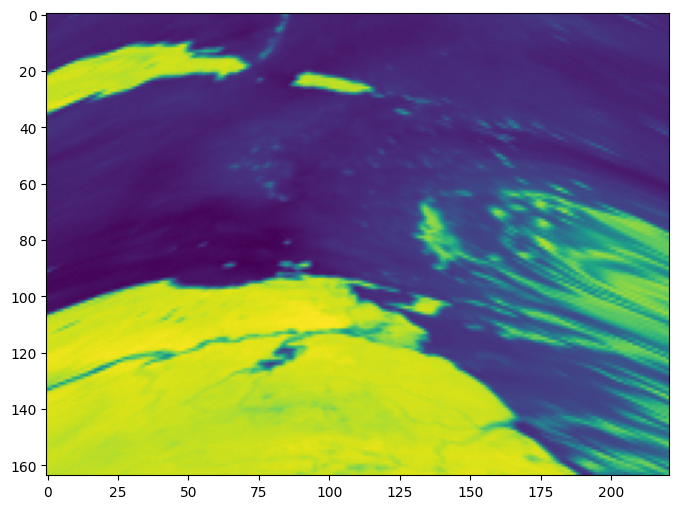

In [59]:
pmw_source = [(src, i) for src, i in sample.keys() if 'pmw' in src][0]
plt.figure(figsize=(12, 6))
plt.imshow(sample[pmw_source]['values'][0], cmap='viridis')

## ERA5 data

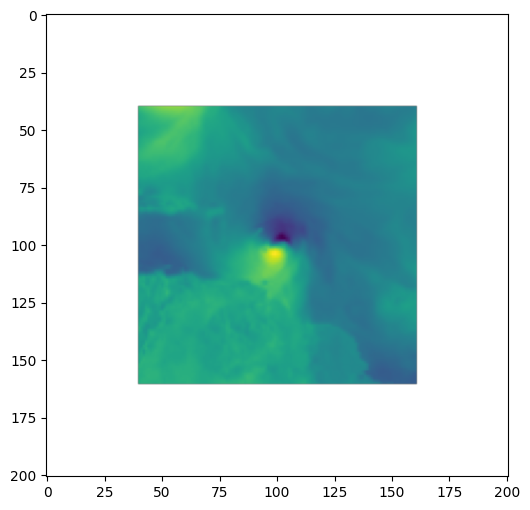

In [60]:
plt.figure(figsize=(12, 6))
# Variable 1 is the u-wind component at 10m
plt.imshow(sample[('tc_primed_era5', 0)]['values'][1], cmap='viridis')

## Infrared data

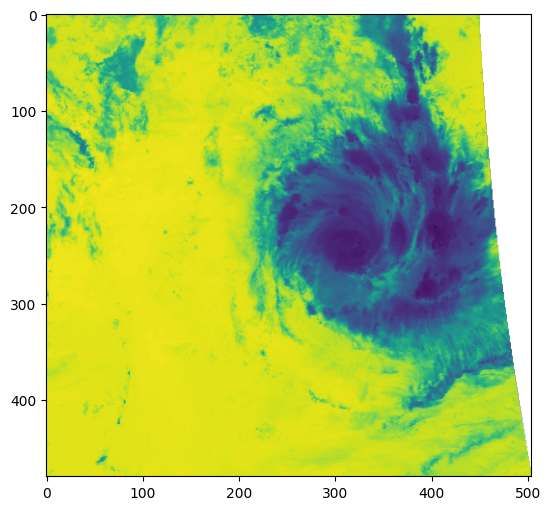

In [61]:
ir_source = [(src, i) for src, i in sample.keys() if 'ir' in src][0]
plt.figure(figsize=(12, 6))
plt.imshow(sample[ir_source]['values'][0], cmap='viridis')

## SAR data

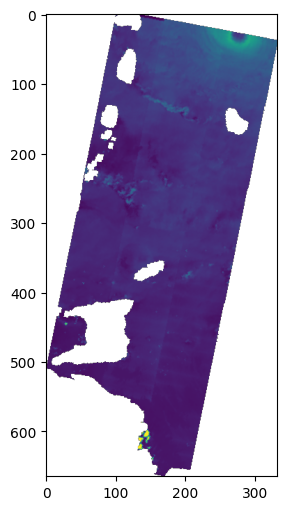

In [62]:
plt.figure(figsize=(12, 6))
plt.imshow(sample[('sar_cband', 0)]['values'][0], cmap='viridis')